# **Library, Seed, ang Path**

# TAHAP 1 – Preprocessing Data

Notebook ini melakukan seluruh preprocessing data mentah LinkedIn & Coursera menjadi dataset sintetis siap training.
Output akhir: `processed_data.zip` berisi vocabulary, role frequency, data sintetis, dan split info.

In [28]:
import pandas as pd
import numpy as np
import json
import os
import re
import random
from sklearn.model_selection import train_test_split
import zipfile
from collections import defaultdict, Counter

SEED =42
np.random.seed(SEED)
random.seed(SEED)

LINKEDIN_PATH = '/kaggle/input/datasets/husniabdillah/dataset-qlop/MASTERED_DATA_FINAL_MODELING.csv'
COURSERA_PATH = '/kaggle/input/datasets/husniabdillah/dataset-qlop/coursera.csv'

PROCESSED_DIR = '/kaggle/working/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Import Library, Set Seed dan Path Selesai.")

Import Library, Set Seed dan Path Selesai.


# **A. Ekstraksi Daftar Skill Unik dari Data Asli**

# 1. Load Data

In [29]:
df_linkedin = pd.read_csv(LINKEDIN_PATH)
df_coursera = pd.read_csv(COURSERA_PATH, sep=";", encoding='latin-1')

print("Ukuran Linkedind:",df_linkedin.shape)
print("Ukuran Data Coursera:",df_coursera.shape)

Ukuran Linkedind: (13844, 15)
Ukuran Data Coursera: (1980, 25)


# 2. Lowercase and Skill extraction

In [30]:
# Skill data extraction, cleaning, and formatting from LinkedIn and Coursera dataframes.

def clean_skill_list(skill_str, sep):
    if pd.isna(skill_str) or skill_str.strip() == "":
        return []
    return [s.strip().lower() for s in skill_str.split(sep) if s.strip()]

df_linkedin['skill_list'] = df_linkedin['hard_skills'].apply(
    lambda x: clean_skill_list(x, ',')
)

coursera_skills = df_coursera.filter(like='Skills').columns

def clean_and_extract_coursera_skill(row):
    all_skills = []
    for col in coursera_skills:
        val = row[col]
        if pd.notna(val) and str(val).strip() != '':
            skill_bersih = str(val).strip().lower()
            all_skills.append(skill_bersih)
    return all_skills

df_coursera['skill_list'] = df_coursera.apply(clean_and_extract_coursera_skill, axis=1)

print("Extraction done.")

print("\nLinkedin Example:")
print(df_linkedin['skill_list'].iloc[0])
print("\nCoursera Example:")
print(df_coursera['skill_list'].iloc[0])

Extraction done.

Linkedin Example:
['mongodb', 'spring boot', 'git', 'microservices architecture', 'postgresql']

Coursera Example:
['node.js', 'authentications', 'cloud deployment', 'middleware', 'mongodb', 'server side', 'back-end web development', 'role-based access control (rbac)', 'application deployment', 'full-stack web development', 'api testing', 'authorization (computing)', 'redis', 'javascript frameworks', 'json', 'database management', 'typescript', 'javascript', 'database design']


# 3. ALL Unique Skill in coursera + linkedin

In [31]:
# Extracting unique skills from LinkedIn data, sorting, and saving to text file.

all_skills = set()

for skills in df_linkedin['skill_list']:
    all_skills.update(skills)

unique_skills = sorted(list(all_skills))
print(f"Total Unique skill: {len(unique_skills)}")

raw_txt_path = os.path.join(PROCESSED_DIR, "unique_skills_raw.txt")
with open(raw_txt_path, 'w', encoding='utf-8') as f:
    for skill in unique_skills:
        f.write(skill + '\n')

print(f"Daftar skill unik disimpan di: {raw_txt_path}")

Total Unique skill: 494
Daftar skill unik disimpan di: /kaggle/working/processed/unique_skills_raw.txt


# **B. Cleaning, Vocabulary, & Synthethis Dataset**

# 4: Load Stop Words & Synonym Mapping

In [32]:
STOP_SKILLS_PATH = "/kaggle/input/datasets/gilangagung/stop-skills-and-synonim-mapping-dataset/stop_skills.txt"
SYN_MAPPING_PATH = "/kaggle/input/datasets/gilangagung/stop-skills-and-synonim-mapping-dataset/syn_mapping.json"

# Load stop words
with open(STOP_SKILLS_PATH, 'r', encoding='utf-8') as f:
    stop_skills = set(line.strip().lower() for line in f if line.strip())
print(f"Stop skills loaded : {len(stop_skills)}")

# Load synonym mapping
with open(SYN_MAPPING_PATH, 'r', encoding='utf-8') as f:
    syn_mapping = json.load(f)
# mapping lowercase
syn_mapping = {k.lower(): v.lower() for k, v in syn_mapping.items()}
print(f"Synonym mapping loaded : {len(syn_mapping)} pasang")

Stop skills loaded : 26
Synonym mapping loaded : 75 pasang


# 5. Stop Word and Synonim Mappping to Data

In [33]:
def apply_mapping_and_stop(skills, mapping, stops):
    """Change synonim, Then delete all stop skill."""
    cleaned = []
    for s in skills:
        s = s.strip().lower()
        s = mapping.get(s, s)
        if s not in stops:
            cleaned.append(s)
    return cleaned

# LinkedIn
df_linkedin['skill_list_clean'] = df_linkedin['skill_list'].apply(
    lambda x: apply_mapping_and_stop(x, syn_mapping, stop_skills)
)

# Coursera
df_coursera['skill_list_clean'] = df_coursera['skill_list'].apply(
    lambda x: apply_mapping_and_stop(x, syn_mapping, stop_skills)
)

print("Data Cleaning Done")

Data Cleaning Done


# 6. Creating Master Skill List (Vocabulary)

In [34]:
# Creating LinkedIn and Coursera vocabularies, saving them to JSON, and generating cross-platform skill mappings.

all_skills_linkedin = set()
for skills in df_linkedin['skill_list_clean']:
    all_skills_linkedin.update(skills)

skill_list_linkedin = sorted(list(all_skills_linkedin))
N_SKILLS_LINKEDIN = len(skill_list_linkedin)
print(f"Total skill unik LinkedIn: {N_SKILLS_LINKEDIN}")

skill_to_idx_linkedin = {skill: i for i, skill in enumerate(skill_list_linkedin)}
idx_to_skill_linkedin = {i: skill for skill, i in skill_to_idx_linkedin.items()}

vocab_linkedin_path = os.path.join(PROCESSED_DIR, "skill_vocab_linkedin.json")
with open(vocab_linkedin_path, 'w', encoding='utf-8') as f:
    json.dump({
        "skill_to_idx": skill_to_idx_linkedin,
        "idx_to_skill": idx_to_skill_linkedin,
        "vocab_size": N_SKILLS_LINKEDIN
    }, f, indent=2)
print(" Vocabulary LinkedIn disimpan.")

all_skills_coursera = set()
for skills in df_coursera['skill_list_clean']:
    all_skills_coursera.update(skills)

skill_list_coursera = sorted(list(all_skills_coursera))
N_SKILLS_COURSERA = len(skill_list_coursera)
print(f"Total skill unik Coursera: {N_SKILLS_COURSERA}")

skill_to_idx_coursera = {skill: i for i, skill in enumerate(skill_list_coursera)}
idx_to_skill_coursera = {i: skill for skill, i in skill_to_idx_coursera.items()}

vocab_coursera_path = os.path.join(PROCESSED_DIR, "skill_vocab_coursera.json")
with open(vocab_coursera_path, 'w', encoding='utf-8') as f:
    json.dump({
        "skill_to_idx": skill_to_idx_coursera,
        "idx_to_skill": idx_to_skill_coursera,
        "vocab_size": N_SKILLS_COURSERA
    }, f, indent=2)
print(" Vocabulary Coursera disimpan.")

manual_mapping_path = "/kaggle/input/datasets/gilangagung/manual-mapping-from-linkedin-to-coursera/manual_mapping.json"
linkedin_to_coursera = {}

from difflib import get_close_matches
coursera_vocab = list(skill_to_idx_coursera.keys())

if os.path.exists(manual_mapping_path):
    with open(manual_mapping_path, 'r', encoding='utf-8') as f:
        manual_map = json.load(f)
    for skill, targets in manual_map.items():
        if skill in skill_to_idx_linkedin:
            valid_targets = [t for t in targets if t in skill_to_idx_coursera]
            if valid_targets:
                linkedin_to_coursera[skill] = valid_targets
    print(" Manual mapping loaded.")
else:
    print(" No manual mapping file. Will use fuzzy matching entirely.")

for skill in skill_list_linkedin:
    if skill in linkedin_to_coursera:
        continue
    
    if skill in skill_to_idx_coursera:
        linkedin_to_coursera[skill] = [skill]
    else:
        match = get_close_matches(skill, coursera_vocab, n=1, cutoff=0.7)
        if match:
            linkedin_to_coursera[skill] = [match[0]]

mapping_path = os.path.join(PROCESSED_DIR, "linkedin_to_coursera_mapping.json")
with open(mapping_path, 'w', encoding='utf-8') as f:
    json.dump(linkedin_to_coursera, f, indent=2)
print(" Mapping LinkedIn -> Coursera disimpan.")

Total skill unik LinkedIn: 489
 Vocabulary LinkedIn disimpan.
Total skill unik Coursera: 1999
 Vocabulary Coursera disimpan.
 Manual mapping loaded.
 Mapping LinkedIn -> Coursera disimpan.


# 7. Skill Frequency Per Role

In [35]:
# Calculating LinkedIn job role metrics including skill frequencies, versatility, time trends, and role affinity.

ROLE_COL = 'role_label'

role_skill_counter = defaultdict(Counter)
role_counts = defaultdict(int)

for _, row in df_linkedin.iterrows():
    role = row[ROLE_COL]
    if pd.isna(role):
        continue
    role_counts[role] += 1
    for skill in row['skill_list_clean']:
        role_skill_counter[role][skill] += 1

role_freq_raw = {}
for role, counter in role_skill_counter.items():
    total = role_counts[role]
    role_freq_raw[role] = {skill: count / total for skill, count in counter.items()}

skill_roles = defaultdict(set)
for role, counter in role_skill_counter.items():
    for skill in counter:
        skill_roles[skill].add(role)
N_ROLES = len(role_counts)
versatility = {skill: len(roleset) / N_ROLES for skill, roleset in skill_roles.items()}

df_linkedin['postedAt_dt'] = pd.to_datetime(df_linkedin['postedAt'], dayfirst=True, errors='coerce')
cutoff = df_linkedin['postedAt_dt'].max() - pd.DateOffset(months=6)
recent = df_linkedin[df_linkedin['postedAt_dt'] >= cutoff]
older = df_linkedin[df_linkedin['postedAt_dt'] < cutoff]

def count_skill_occurrences(df):
    c = Counter()
    for skills in df['skill_list_clean']:
        c.update(skills)
    return c

recent_counter = count_skill_occurrences(recent)
older_counter = count_skill_occurrences(older)

trend = {}
for skill in skill_list_linkedin:
    f_recent = recent_counter.get(skill, 0) / max(len(recent), 1)
    f_older = older_counter.get(skill, 0) / max(len(older), 1)
    raw_trend = (f_recent - f_older) + 0.5
    trend[skill] = max(0.0, min(1.0, raw_trend))

role_freq = {}
for role, counter in role_skill_counter.items():
    max_freq = max(counter.values()) if counter else 1
    role_freq[role] = {skill: count / max_freq for skill, count in counter.items()}

freq_path = os.path.join(PROCESSED_DIR, "role_freq.json")
with open(freq_path, 'w', encoding='utf-8') as f:
    json.dump(role_freq, f, indent=2)

print(" Role frequency, versatility, trend siap (LinkedIn).")
print(f"Total role: {N_ROLES}")

role_affinity = {}
for role in role_counts.keys():
    affinity_dict = {}
    for skill in role_skill_counter[role]:
        freq_target = role_skill_counter[role][skill]
        freq_other = sum(role_skill_counter[other].get(skill, 0) for other in role_counts if other != role)
        total = freq_target + freq_other
        if total > 0:
            affinity_dict[skill] = freq_target / total
        else:
            affinity_dict[skill] = 0.0
    role_affinity[role] = affinity_dict

 Role frequency, versatility, trend siap (LinkedIn).
Total role: 27


# 8. Generate Synthethis User for Skill Priority Scorer Model (20k Sample)

In [36]:
# Synthetic user data generation and multi-hot vector encoding for Skill Priority Scorer

N_USERS = 20000
REALISTIC_RATIO = 0.8
N_REALISTIC = int(N_USERS * REALISTIC_RATIO)
N_RANDOM = N_USERS - N_REALISTIC

roles = list(role_freq.keys())
role_list_indices = {role: i for i, role in enumerate(roles)}

min_skills = 2
max_skills = 12

def make_multihot_linkedin(skills):
    vec = np.zeros(N_SKILLS_LINKEDIN, dtype=np.float32)
    for s in skills:
        if s in skill_to_idx_linkedin:
            vec[skill_to_idx_linkedin[s]] = 1.0
    return vec

jobs_per_role = defaultdict(list)
for _, row in df_linkedin.iterrows():
    role = row[ROLE_COL]
    if pd.notna(role):
        jobs_per_role[role].append(set(row['skill_list_clean']))

X_users = np.zeros((N_USERS, N_SKILLS_LINKEDIN), dtype=np.float32)
X_roles = np.zeros(N_USERS, dtype=np.int32)
Y_targets = np.zeros((N_USERS, N_SKILLS_LINKEDIN), dtype=np.float32)

ALPHA = 2.0

for i in range(N_REALISTIC):
    role = random.choice(roles)
    X_roles[i] = role_list_indices[role]

    skills_pool = list(role_freq_raw[role].keys())
    probs = np.array([role_freq_raw[role][s] for s in skills_pool])
    probs = probs / probs.sum()

    n_skill = min(random.randint(min_skills, max_skills), len(skills_pool))
    chosen_skills = np.random.choice(skills_pool, size=n_skill, replace=False, p=probs)
    X_users[i] = make_multihot_linkedin(chosen_skills)

    owned_set = set(chosen_skills)
    relevant_jobs = [job for job in jobs_per_role[role] if owned_set.intersection(job)]
    total_rel = len(relevant_jobs) if relevant_jobs else 1

    target_vec = np.zeros(N_SKILLS_LINKEDIN, dtype=np.float32)
    for skill, freq in role_freq_raw[role].items():
        if skill in owned_set:
            continue
        idx = skill_to_idx_linkedin.get(skill, -1)
        if idx == -1:
            continue
        f = freq
        cooc = sum(1 for job in relevant_jobs if skill in job) / total_rel
        v = versatility.get(skill, 0.0)
        t = trend.get(skill, 0.5)
        aff = role_affinity.get(role, {}).get(skill, 0.0)
        raw = (2*f + cooc + v + t + 3*aff) / 8.0
        target_vec[idx] = 1.0 - np.exp(-ALPHA * raw)
    Y_targets[i] = target_vec

for i in range(N_REALISTIC, N_USERS):
    role = random.choice(roles)
    X_roles[i] = role_list_indices[role]

    n_skill = random.randint(min_skills, max_skills)
    chosen_skills = random.sample(skill_list_linkedin, min(n_skill, N_SKILLS_LINKEDIN))
    X_users[i] = make_multihot_linkedin(chosen_skills)

    owned_set = set(chosen_skills)
    relevant_jobs = [job for job in jobs_per_role[role] if owned_set.intersection(job)]
    total_rel = len(relevant_jobs) if relevant_jobs else 1

    target_vec = np.zeros(N_SKILLS_LINKEDIN, dtype=np.float32)
    for skill, freq in role_freq_raw.get(role, {}).items():
        if skill in owned_set:
            continue
        idx = skill_to_idx_linkedin.get(skill, -1)
        if idx == -1:
            continue
        f = freq
        cooc = sum(1 for job in relevant_jobs if skill in job) / total_rel
        v = versatility.get(skill, 0.0)
        t = trend.get(skill, 0.5)
        aff = role_affinity.get(role, {}).get(skill, 0.0)
        raw = (2*f + cooc + v + t + 3*aff) / 8.0
        target_vec[idx] = 1.0 - np.exp(-ALPHA * raw)
    Y_targets[i] = target_vec

npz_path = os.path.join(PROCESSED_DIR, "synthetic_users_skill_priority_scorer.npz")
np.savez_compressed(
    npz_path,
    X_users=X_users,
    X_roles=X_roles,
    Y_targets=Y_targets,
    role_list=roles,
    N_SKILLS=N_SKILLS_LINKEDIN,
    N_ROLES=N_ROLES
)
print(f" User sintetis disimpan: {npz_path}")
print(f"    Shape X_users: {X_users.shape}, Y_targets: {Y_targets.shape}")

 User sintetis disimpan: /kaggle/working/processed/synthetic_users_skill_priority_scorer.npz
    Shape X_users: (20000, 489), Y_targets: (20000, 489)


VISUALISASI DATA SINTETIS - SKILL PRIORITY SCORER


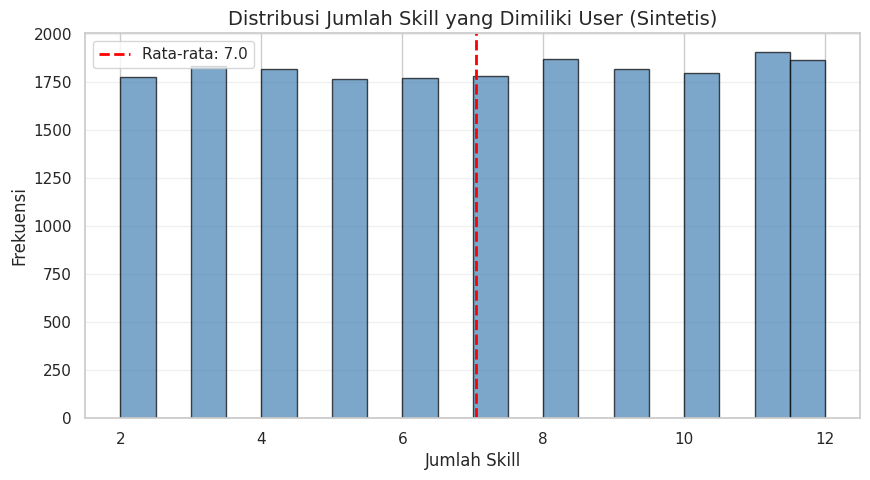

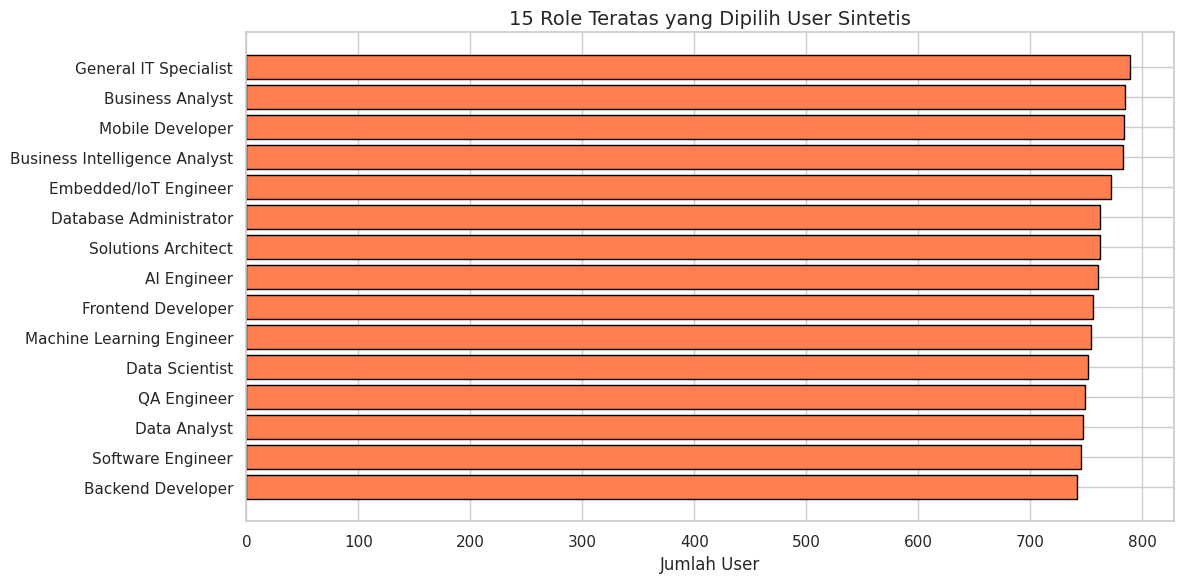

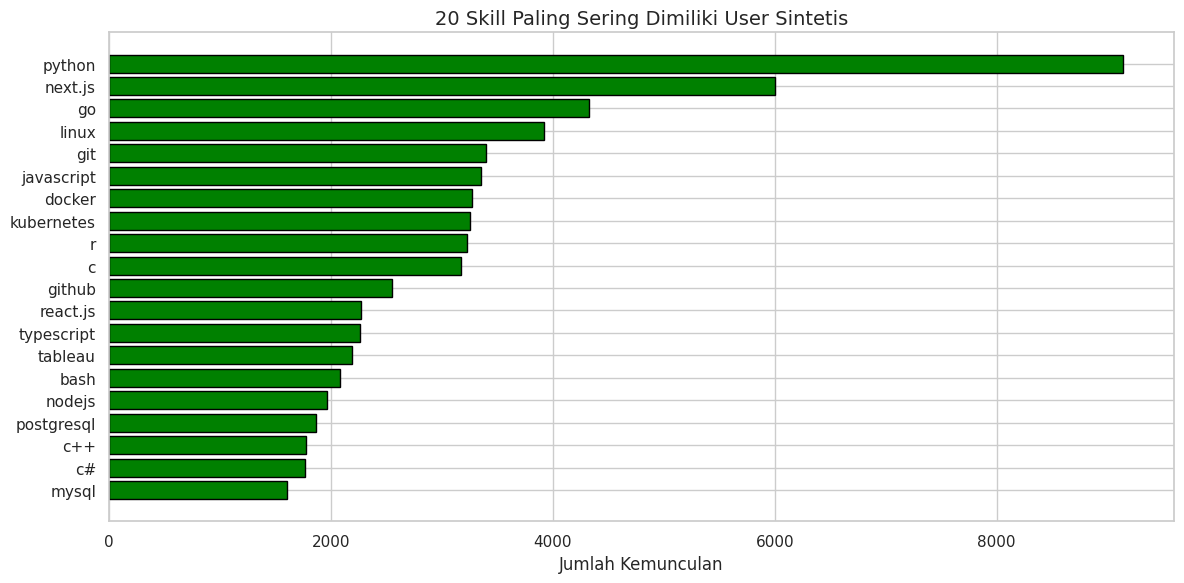

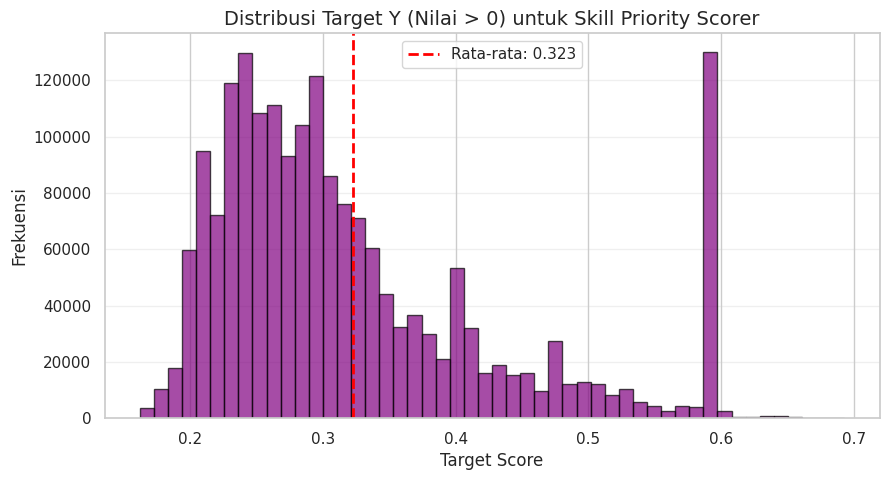

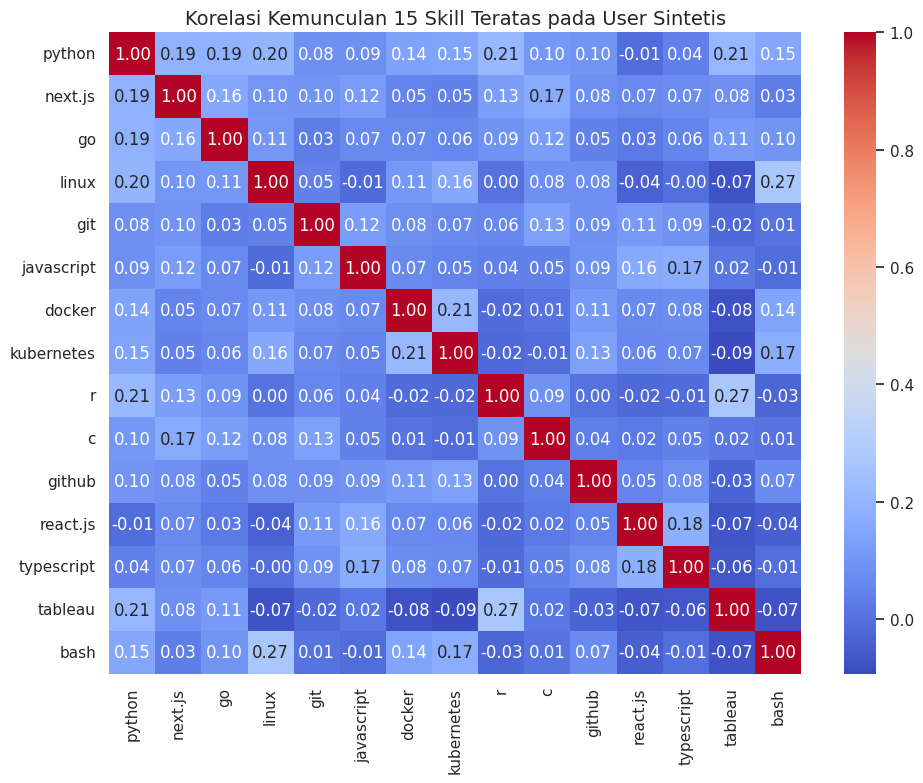


Semua visualisasi Skill Priority Scorer selesai.



In [37]:
# Script visualizes synthetic data distributions and skill correlation matrix.

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

print("=" * 60)
print("VISUALISASI DATA SINTETIS - SKILL PRIORITY SCORER")
print("=" * 60)

skill_counts = np.sum(X_users, axis=1)
plt.figure(figsize=(10, 5))
plt.hist(skill_counts, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
plt.title("Distribusi Jumlah Skill yang Dimiliki User (Sintetis)", fontsize=14)
plt.xlabel("Jumlah Skill")
plt.ylabel("Frekuensi")
mean_skills = np.mean(skill_counts)
plt.axvline(
    mean_skills,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Rata-rata: {mean_skills:.1f}",
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

role_indices = X_roles.astype(int)
role_counts_vis = Counter(role_indices)
sorted_roles = sorted(role_counts_vis.items(), key=lambda x: x[1], reverse=True)[
    :15
]
role_names_top = [roles[idx] for idx, _ in sorted_roles]
role_values_top = [count for _, count in sorted_roles]

plt.figure(figsize=(12, 6))
plt.barh(
    role_names_top[::-1], role_values_top[::-1], color="coral", edgecolor="black"
)
plt.title("15 Role Teratas yang Dipilih User Sintetis", fontsize=14)
plt.xlabel("Jumlah User")
plt.tight_layout()
plt.show()

skill_total = np.sum(X_users, axis=0)
top_skill_indices = np.argsort(skill_total)[::-1][:20]
top_skill_names = [skill_list_linkedin[i] for i in top_skill_indices]
top_skill_counts = skill_total[top_skill_indices]

plt.figure(figsize=(12, 6))
plt.barh(
    top_skill_names[::-1], top_skill_counts[::-1], color="green", edgecolor="black"
)
plt.title("20 Skill Paling Sering Dimiliki User Sintetis", fontsize=14)
plt.xlabel("Jumlah Kemunculan")
plt.tight_layout()
plt.show()

flat_targets = Y_targets.flatten()
flat_targets = flat_targets[flat_targets > 0]
plt.figure(figsize=(10, 5))
plt.hist(flat_targets, bins=50, edgecolor="black", alpha=0.7, color="purple")
plt.title(
    "Distribusi Target Y (Nilai > 0) untuk Skill Priority Scorer", fontsize=14
)
plt.xlabel("Target Score")
plt.ylabel("Frekuensi")
mean_target = np.mean(flat_targets)
plt.axvline(
    mean_target,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Rata-rata: {mean_target:.3f}",
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

top15_indices = np.argsort(skill_total)[::-1][:15]
top15_names = [skill_list_linkedin[i] for i in top15_indices]
corr_matrix = np.corrcoef(X_users[:, top15_indices].T)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=top15_names,
    yticklabels=top15_names,
)
plt.title(
    "Korelasi Kemunculan 15 Skill Teratas pada User Sintetis", fontsize=14
)
plt.tight_layout()
plt.show()

print("\nSemua visualisasi Skill Priority Scorer selesai.\n")

# 9. Generate Synthetic Demand for Course Recomendation Model

In [38]:
# Synthetic demand data generation with SBERT category affinity modeling.

import numpy as np
import pandas as pd
from collections import Counter
from sentence_transformers import SentenceTransformer

N_DEMAND = 15000
TOP_K_SKILLS_DEMAND = 15

global_skill_freq = Counter()
for skills in df_linkedin['skill_list_clean']:
    global_skill_freq.update(skills)

skills_with_freq = [s for s in skill_list_linkedin if s in global_skill_freq]
if not skills_with_freq:
    skills_with_freq = skill_list_linkedin
freq_weights = np.array([global_skill_freq.get(s, 1) for s in skills_with_freq], dtype=np.float32)
freq_weights = freq_weights / freq_weights.sum()

def make_multihot_coursera(skills):
    vec = np.zeros(N_SKILLS_COURSERA, dtype=np.float32)
    for s in skills:
        if s in skill_to_idx_coursera:
            vec[skill_to_idx_coursera[s]] = 1.0
    return vec

course_vectors_coursera = []
course_names = []
course_urls = []
course_difficulty = []
course_duration = []
course_job_categories = []

for _, row in df_coursera.iterrows():
    vec = make_multihot_coursera(row['skill_list_clean'])
    course_vectors_coursera.append(vec)
    course_names.append(row.get('Name', 'Unknown'))
    course_urls.append(row.get('Url', ''))
    course_difficulty.append(row.get('Difficulty', 'INTERMEDIATE'))
    course_duration.append(row.get('Duration', 'ONE_TO_THREE_MONTHS'))
    cat = row.get('Job category', '')
    if pd.isna(cat) or str(cat).strip() == '':
        cat = 'Unknown'
    course_job_categories.append(str(cat).strip())

course_vectors_coursera = np.array(course_vectors_coursera, dtype=np.float32)
N_COURSES = len(course_vectors_coursera)

bobot_coursera = np.ones(N_SKILLS_COURSERA, dtype=np.float32)
for skill_c, idx_c in skill_to_idx_coursera.items():
    if skill_c in global_skill_freq:
        bobot_coursera[idx_c] = global_skill_freq[skill_c]

linkedin_to_coursera_indices = [[] for _ in range(N_SKILLS_LINKEDIN)]
for skill_li, coursera_list in linkedin_to_coursera.items():
    if skill_li in skill_to_idx_linkedin:
        idx_li = skill_to_idx_linkedin[skill_li]
        for cs in coursera_list:
            if cs in skill_to_idx_coursera:
                linkedin_to_coursera_indices[idx_li].append(skill_to_idx_coursera[cs])

roles = list(role_freq.keys())
role_counts = Counter(df_linkedin['role_label'].dropna())
role_probs = np.array([role_counts.get(r, 1) for r in roles], dtype=np.float32)
role_probs = role_probs / role_probs.sum()

np.random.seed(SEED)
demand_roles = np.random.choice(roles, size=N_DEMAND, p=role_probs)

print("Loading SBERT model for category affinity...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

role_embeddings = {}
for role in roles:
    role_embeddings[role] = sbert_model.encode([role], convert_to_tensor=False)[0].astype(np.float32)

unique_categories = list(set(course_job_categories))
cat_embeddings = {}
for cat in unique_categories:
    cat_embeddings[cat] = sbert_model.encode([cat], convert_to_tensor=False)[0].astype(np.float32)
print("Category embeddings computed.")

demand_vectors = np.zeros((N_DEMAND, N_SKILLS_LINKEDIN), dtype=np.float32)
course_indices = np.zeros(N_DEMAND, dtype=np.int32)
targets = np.zeros(N_DEMAND, dtype=np.float32)
demand_coursera_list = []

CAT_AFF_BASE = 0.4
CAT_AFF_SCALE = 0.6

for i in range(N_DEMAND):
    chosen = np.random.choice(skills_with_freq, size=TOP_K_SKILLS_DEMAND, replace=False, p=freq_weights)
    dvec_li = np.zeros(N_SKILLS_LINKEDIN, dtype=np.float32)
    for skill in chosen:
        idx = skill_to_idx_linkedin.get(skill, -1)
        if idx != -1:
            dvec_li[idx] = 1.0
    demand_vectors[i] = dvec_li

    dvec_cr = np.zeros(N_SKILLS_COURSERA, dtype=np.float32)
    for idx_li in np.where(dvec_li == 1.0)[0]:
        for idx_cr in linkedin_to_coursera_indices[idx_li]:
            dvec_cr[idx_cr] = 1.0
    demand_coursera_list.append(dvec_cr)

    overlap_scores = np.sum(dvec_cr * course_vectors_coursera, axis=1)
    valid_courses = np.where(overlap_scores > 0)[0]
    if len(valid_courses) == 0:
        c_idx = np.random.randint(0, N_COURSES)
    else:
        c_idx = np.random.choice(valid_courses)
    course_indices[i] = c_idx
    cvec = course_vectors_coursera[c_idx]

    masked = dvec_cr * cvec
    wcov_num = np.sum(masked * bobot_coursera)
    wcov_den = np.sum(dvec_cr * bobot_coursera)
    wcov = wcov_num / wcov_den if wcov_den > 0 else 0.0

    intersection = np.sum(masked)
    union = np.sum(np.clip(dvec_cr + cvec, 0, 1))
    jac = intersection / union if union > 0 else 0.0
    prec = intersection / np.sum(cvec) if np.sum(cvec) > 0 else 0.0

    overlap = (wcov + jac + prec) / 3.0

    role = demand_roles[i]
    job_cat = course_job_categories[c_idx]
    role_emb = role_embeddings[role]
    cat_emb = cat_embeddings[job_cat]
    cos_sim = np.dot(role_emb, cat_emb) / (np.linalg.norm(role_emb) * np.linalg.norm(cat_emb) + 1e-9)
    cos_sim = max(0.0, min(cos_sim, 1.0))
    multiplier = CAT_AFF_BASE + CAT_AFF_SCALE * cos_sim

    targets[i] = overlap * multiplier

demand_coursera_arr = np.array(demand_coursera_list, dtype=np.float32)

demand_weighted = demand_coursera_arr * bobot_coursera.astype(np.float32)
wcov_num = demand_weighted @ course_vectors_coursera.T
wcov_den = demand_weighted.sum(axis=1, keepdims=True)
wcov_all = wcov_num / np.maximum(wcov_den, 1e-8)

intersection = demand_coursera_arr @ course_vectors_coursera.T
demand_sums = demand_coursera_arr.sum(axis=1, keepdims=True)
course_sums = course_vectors_coursera.sum(axis=1)
union = demand_sums + course_sums - intersection
jac_all = intersection / np.maximum(union, 1e-8)
prec_all = intersection / np.maximum(course_sums, 1e-8)

overlap_all = (wcov_all + jac_all + prec_all) / 3.0
max_overlap = overlap_all.max(axis=1)
targets_before_norm = targets.copy()

targets = targets / np.maximum(max_overlap, 1e-8)

npz_demand_path = os.path.join(PROCESSED_DIR, "synthetic_demand_course_two_tower.npz")
np.savez_compressed(
    npz_demand_path,
    demand_vectors=demand_vectors,
    course_vectors=course_vectors_coursera,
    course_indices=course_indices,
    targets=targets,
    course_names=course_names,
    course_urls=course_urls
)
print(f" Demand sintetis dengan Category Affinity disimpan: {npz_demand_path}")

Loading SBERT model for category affinity...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Category embeddings computed.
 Demand sintetis dengan Category Affinity disimpan: /kaggle/working/processed/synthetic_demand_course_two_tower.npz


VISUALISASI DATA SINTETIS - TWO-TOWER COURSE MODEL


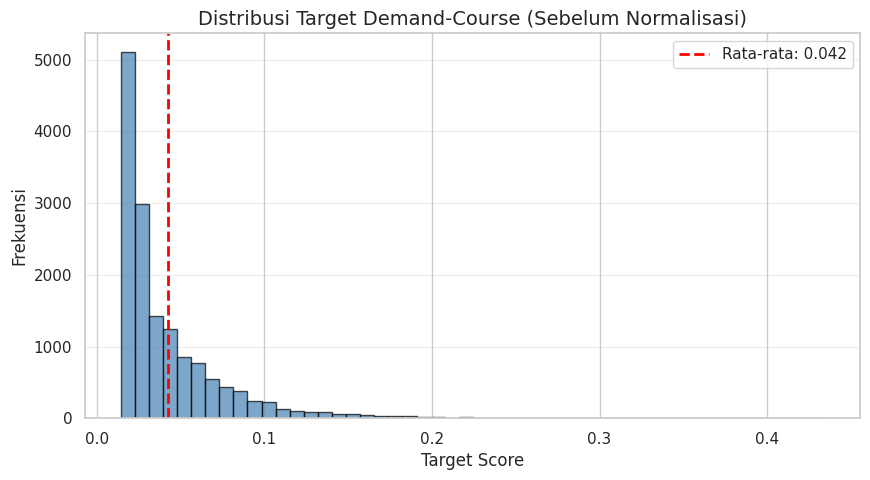

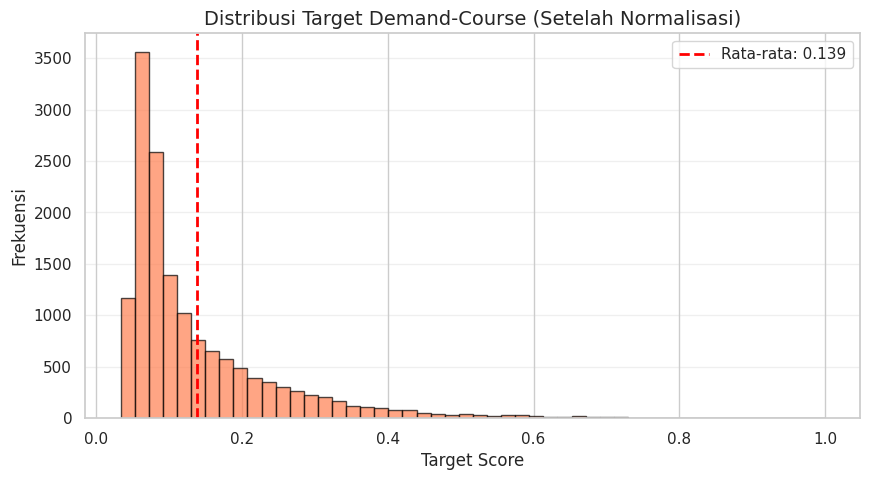

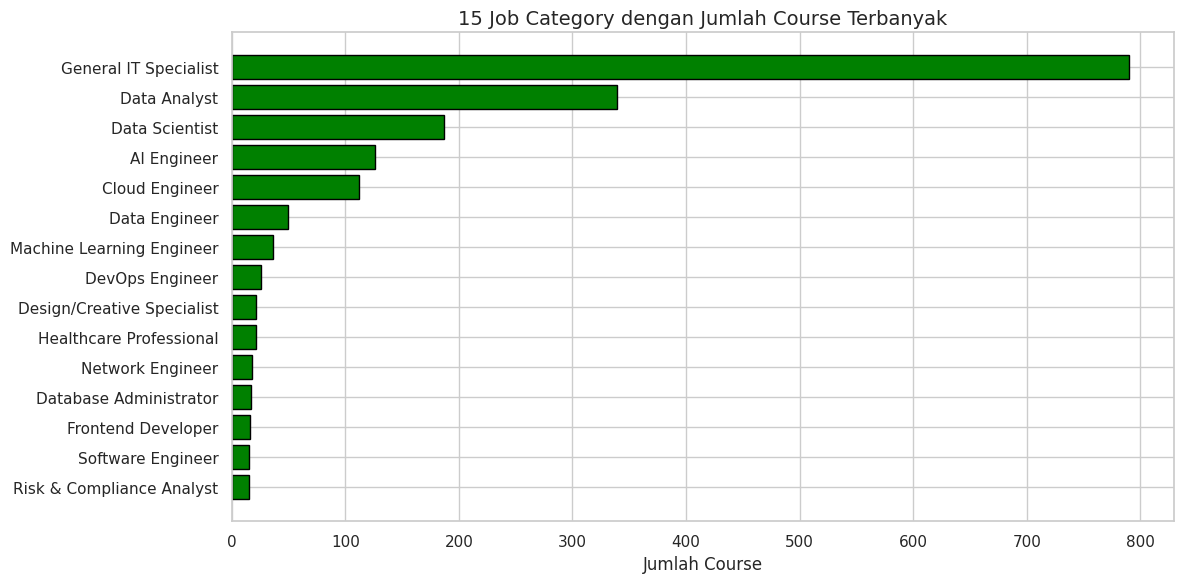

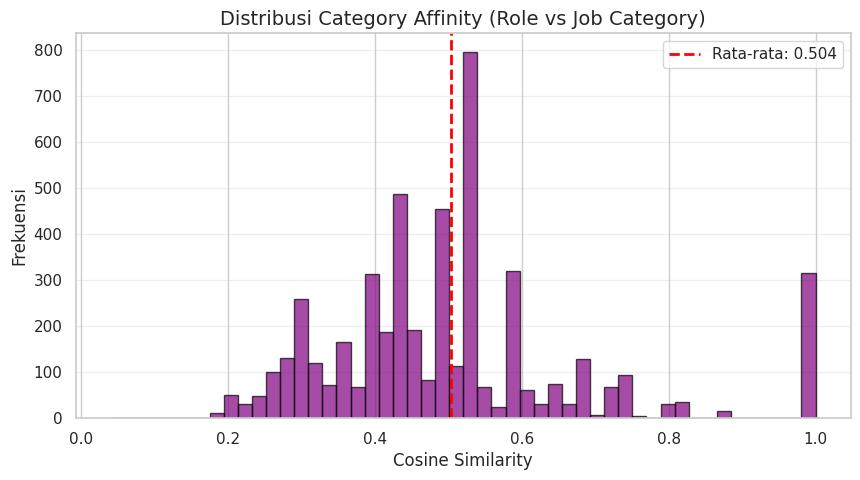

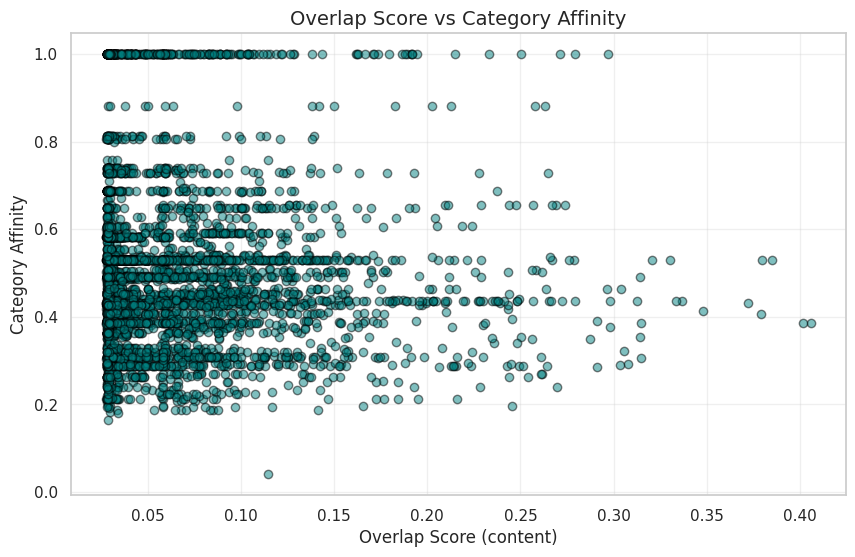


Semua visualisasi Two-Tower Course Model selesai.



In [39]:
# visualizes synthetic data for Two-Tower Course Model.

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

print("=" * 60)
print("VISUALISASI DATA SINTETIS - TWO-TOWER COURSE MODEL")
print("=" * 60)

plt.figure(figsize=(10, 5))
plt.hist(
    targets_before_norm, bins=50, edgecolor="black", alpha=0.7, color="steelblue"
)
plt.title("Distribusi Target Demand-Course (Sebelum Normalisasi)", fontsize=14)
plt.xlabel("Target Score")
plt.ylabel("Frekuensi")
mean_before = np.mean(targets_before_norm)
plt.axvline(
    mean_before,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Rata-rata: {mean_before:.3f}",
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(targets, bins=50, edgecolor="black", alpha=0.7, color="coral")
plt.title("Distribusi Target Demand-Course (Setelah Normalisasi)", fontsize=14)
plt.xlabel("Target Score")
plt.ylabel("Frekuensi")
mean_after = np.mean(targets)
plt.axvline(
    mean_after,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Rata-rata: {mean_after:.3f}",
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

cat_counts = Counter(course_job_categories)
top_cats = cat_counts.most_common(15)
cats, counts_cat = zip(*top_cats)
plt.figure(figsize=(12, 6))
plt.barh(cats[::-1], counts_cat[::-1], color="green", edgecolor="black")
plt.title("15 Job Category dengan Jumlah Course Terbanyak", fontsize=14)
plt.xlabel("Jumlah Course")
plt.tight_layout()
plt.show()

sample_size = min(5000, N_DEMAND)
affinities = []
for i in range(sample_size):
    role = demand_roles[i]
    job_cat = course_job_categories[course_indices[i]]
    role_emb = role_embeddings[role]
    cat_emb = cat_embeddings[job_cat]
    cos_sim = np.dot(role_emb, cat_emb) / (
        np.linalg.norm(role_emb) * np.linalg.norm(cat_emb) + 1e-9
    )
    affinities.append(max(0.0, min(cos_sim, 1.0)))

plt.figure(figsize=(10, 5))
plt.hist(affinities, bins=50, edgecolor="black", alpha=0.7, color="purple")
plt.title("Distribusi Category Affinity (Role vs Job Category)", fontsize=14)
plt.xlabel("Cosine Similarity")
plt.ylabel("Frekuensi")
mean_aff = np.mean(affinities)
plt.axvline(
    mean_aff,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Rata-rata: {mean_aff:.3f}",
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

overlaps_sample = []
affinities_sample = []
for i in range(sample_size):
    dvec_cr = demand_coursera_list[i]
    cvec = course_vectors_coursera[course_indices[i]]
    masked = dvec_cr * cvec
    wcov_num = np.sum(masked * bobot_coursera)
    wcov_den = np.sum(dvec_cr * bobot_coursera)
    wcov = wcov_num / wcov_den if wcov_den > 0 else 0.0
    intersection = np.sum(masked)
    union = np.sum(np.clip(dvec_cr + cvec, 0, 1))
    jac = intersection / union if union > 0 else 0.0
    prec = intersection / np.sum(cvec) if np.sum(cvec) > 0 else 0.0
    overlaps_sample.append((wcov + jac + prec) / 3.0)

    role = demand_roles[i]
    job_cat = course_job_categories[course_indices[i]]
    role_emb = role_embeddings[role]
    cat_emb = cat_embeddings[job_cat]
    cos_sim = np.dot(role_emb, cat_emb) / (
        np.linalg.norm(role_emb) * np.linalg.norm(cat_emb) + 1e-9
    )
    affinities_sample.append(max(0.0, min(cos_sim, 1.0)))

plt.figure(figsize=(10, 6))
plt.scatter(
    overlaps_sample, affinities_sample, alpha=0.5, c="teal", edgecolor="black"
)
plt.xlabel("Overlap Score (content)")
plt.ylabel("Category Affinity")
plt.title("Overlap Score vs Category Affinity", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

print("\nSemua visualisasi Two-Tower Course Model selesai.\n")

#  10. Data Split (Training and Validation,  80 : 20)

In [40]:
#  10. Data Split (Training, Validation, Testing)
# Splitting synthetic user data and demand data into 70% train, 15% validation, 15% test.

# For Skill Priority Scorer Model
indices_user = np.arange(N_USERS)
# Pertama, pisahkan train (70%) dan temp (30%)
train_idx_u, temp_idx_u = train_test_split(indices_user, test_size=0.3, random_state=SEED)
# Lalu, pisahkan temp menjadi validation (15%) dan testing (15%)
val_idx_u, test_idx_u = train_test_split(temp_idx_u, test_size=0.5, random_state=SEED)

# For Two-Tower Course Model
indices_demand = np.arange(N_DEMAND)
train_idx_d, temp_idx_d = train_test_split(indices_demand, test_size=0.3, random_state=SEED)
val_idx_d, test_idx_d = train_test_split(temp_idx_d, test_size=0.5, random_state=SEED)

split_info = {
    "skill_priority_scorer": {
        "train_indices": train_idx_u.tolist(),
        "val_indices": val_idx_u.tolist(),
        "test_indices": test_idx_u.tolist()
    },
    "two_tower_course": {
        "train_indices": train_idx_d.tolist(),
        "val_indices": val_idx_d.tolist(),
        "test_indices": test_idx_d.tolist()
    },
    "random_seed": SEED
}
split_path = os.path.join(PROCESSED_DIR, "train_test_split_info.json")
with open(split_path, 'w') as f:
    json.dump(split_info, f, indent=2)
print(f" Split (train/val/test) Saved in: {split_path}")

 Split (train/val/test) Saved in: /kaggle/working/processed/train_test_split_info.json


# 11. Zip All Processed Data

In [41]:
# Exporting processed Coursera data to CSV and compressing the output directory into a ZIP archive.

coursera_csv_path = os.path.join(PROCESSED_DIR, "coursera_cleaned.csv")
df_coursera.to_csv(coursera_csv_path, index=False)

zip_path = "/kaggle/working/processed_data.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(PROCESSED_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, PROCESSED_DIR)
            zipf.write(full_path, arcname)

print(f" All Processed Data Zipped in: {zip_path}")

 All Processed Data Zipped in: /kaggle/working/processed_data.zip
